started


I0000 00:00:1761830429.053389      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/15


I0000 00:00:1761830435.955934     124 service.cc:148] XLA service 0x7b1f580079a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761830435.956408     124 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1761830436.422395     124 cuda_dnn.cc:529] Loaded cuDNN version 90300


 47/629 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3600 - loss: 1.6927

I0000 00:00:1761830439.179733     124 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


629/629 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.4737 - loss: 1.2523 - val_accuracy: 0.6161 - val_loss: 0.8300
Epoch 2/15
629/629 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6300 - loss: 0.8463 - val_accuracy: 0.7121 - val_loss: 0.6764
Epoch 3/15
629/629 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7064 - loss: 0.7029 - val_accuracy: 0.7199 - val_loss: 0.6594
Epoch 4/15
629/629 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7526 - loss: 0.5994 - val_accuracy: 0.7820 - val_loss: 0.5315
Epoch 5/15
629/629 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7818 - loss: 0.5271 - val_accuracy: 0.7739 - val_loss: 0.5545
Epoch 6/15
629/629 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8121 - loss: 0.4698 - val_accuracy: 0.8266 - val_loss: 0.4333
Epoch 7/15
629/629 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8271 - loss: 0.4329 - val_accuracy: 0.8255 - val_loss: 0.4515
Epoch 8/15
629/629 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8496 - loss: 0.3878 - val_accuracy: 0.8559 - va

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
842/842 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.4753 - loss: 1.2099 - val_accuracy: 0.6557 - val_loss: 0.7712
Epoch 2/15
842/842 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6781 - loss: 0.7555 - val_accuracy: 0.7207 - val_loss: 0.6326
Epoch 3/15
842/842 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7562 - loss: 0.5762 - val_accuracy: 0.7593 - val_loss: 0.5452
Epoch 4/15
842/842 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8016 - loss: 0.4690 - val_accuracy: 0.7799 - val_loss: 0.5076
Epoch 5/15
842/842 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8348 - loss: 0.4089 - val_accuracy: 0.7893 - val_loss: 0.5061
Epoch 6/15
842/842 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8587 - loss: 0.3487 - val_accuracy: 0.7866 - val_loss: 0.5272
Epoch 7/15
842/842 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8869 - loss: 0.2960 - val_accuracy: 0.7854 - val_loss: 0.5721
Epoch 8/15
842/842 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9063 - loss: 0.2505 - val_accuracy: 0

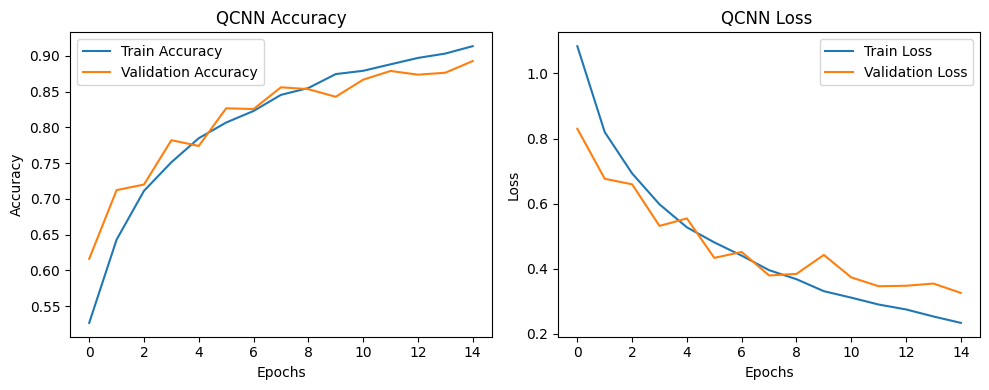

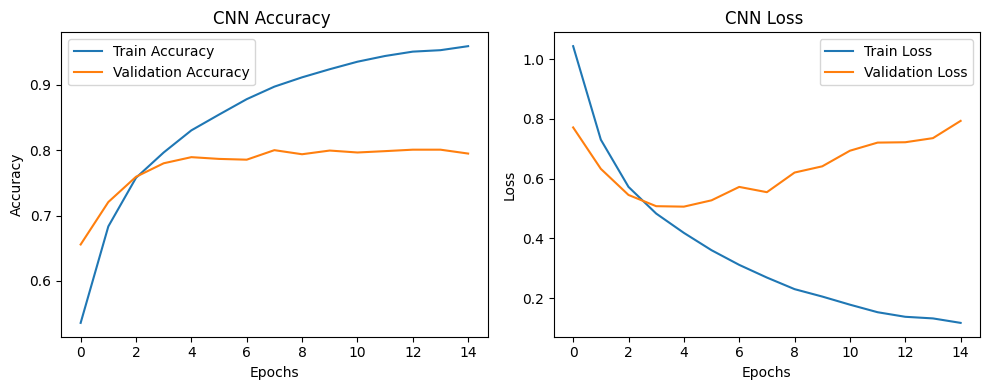

In [3]:
# ==================== IMPORTS & SETUP ====================
print("started")
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras as K
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt

# ==================== PATHS ====================
BASE_PATH = "/kaggle/input/qfeatures-and-mri/Quantum_features_"
COMBINED_PATH = os.path.join(BASE_PATH, "Combined")
DATASET_PATH = os.path.join(BASE_PATH, "data_set", "AugmentedAlzheimerDataset")

# ==================== HYPERPARAMETERS ====================
IMG_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 0.0005

# =========================================================
# PART 1 — QCNN FEED-FORWARD
# =========================================================
X_q = np.load(os.path.join(COMBINED_PATH, "quantum_features_combined.npy"))
y_q = np.load(os.path.join(COMBINED_PATH, "labels_combined.npy"))

Xq_train, Xq_val, yq_train, yq_val = train_test_split(
    X_q, y_q, test_size=0.4, stratify=y_q, random_state=42
)

def make_model(input_dim, num_classes):
    model = K.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Flatten(),
        layers.BatchNormalization(),

        layers.Dense(1024, kernel_initializer="he_uniform"),
        layers.LeakyReLU(negative_slope=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(512, kernel_initializer="he_uniform"),
        layers.LeakyReLU(negative_slope=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        layers.Dense(256, kernel_initializer="he_uniform"),
        layers.LeakyReLU(negative_slope=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.15),

        layers.Dense(128, kernel_initializer="he_uniform"),
        layers.LeakyReLU(negative_slope=0.1),
        layers.BatchNormalization(),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=K.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

qcnn_model = make_model(Xq_train.shape[1], len(np.unique(y_q)))

history_qcnn = qcnn_model.fit(
    Xq_train, yq_train,
    validation_data=(Xq_val, yq_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# =========================================================
#  PART 2 — CNN (1 FILTER 2×2)
# =========================================================
def load_dataset(path, img_size=64):
    images, labels = [], []
    classes = sorted(os.listdir(path))
    for label, cls in enumerate(classes):
        cls_folder = os.path.join(path, cls)
        if not os.path.isdir(cls_folder):
            continue
        for file in tqdm(os.listdir(cls_folder), desc=f"Loading {cls}", leave=False):
            img_path = os.path.join(cls_folder, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            img = img / 255.0
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels), classes

X_cnn, y_cnn, class_names = load_dataset(DATASET_PATH, IMG_SIZE)
X_cnn = X_cnn[..., np.newaxis]

Xc_train, Xc_val, yc_train, yc_val = train_test_split(
    X_cnn, y_cnn, test_size=0.2, stratify=y_cnn, random_state=42
)

cnn_model = K.Sequential([
    layers.Conv2D(1, (2, 2), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1), use_bias=True),
    layers.Flatten(),
    layers.BatchNormalization(),

    layers.Dense(1024, kernel_initializer="he_uniform"),
    layers.LeakyReLU(negative_slope=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(512, kernel_initializer="he_uniform"),
    layers.LeakyReLU(negative_slope=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Dense(256, kernel_initializer="he_uniform"),
    layers.LeakyReLU(negative_slope=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.15),

    layers.Dense(128, kernel_initializer="he_uniform"),
    layers.LeakyReLU(negative_slope=0.1),
    layers.BatchNormalization(),

    layers.Dense(len(class_names), activation="softmax")
])

cnn_model.compile(
    optimizer=K.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_cnn = cnn_model.fit(
    Xc_train, yc_train,
    validation_data=(Xc_val, yc_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# =========================================================
# 📊 INDIVIDUAL MODEL PERFORMANCE PLOTS
# =========================================================

# ----- QCNN -----
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_qcnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_qcnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('QCNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_qcnn.history['loss'], label='Train Loss')
plt.plot(history_qcnn.history['val_loss'], label='Validation Loss')
plt.title('QCNN Loss ')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# ----- CNN -----
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy ')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss ')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
#  SAVE MODELS
# =========================================================
qcnn_model.save("/kaggle/working/qcnn_model_15epochs.h5")
cnn_model.save("/kaggle/working/cnn_model_15epochs.h5")


Extracting Quantum Features: 100%|██████████| 735/735 [35:49<00:00,  2.92s/it]



──────────────── QCNN ────────────────
QConv        | 4 wires      |             
Dense        | 1024         | params: 4,195,328
Dense        | 512          | params: 524,800
Dense        | 256          | params: 131,328
Dense        | 128          | params: 32,896
Dense        | 4            | params: 516
─────────────────────────────────────────────

──────────────── CNN ────────────────
Conv2D       | (2, 2)       | params: 5
Dense        | 1024         | params: 4,065,280
Dense        | 512          | params: 524,800
Dense        | 256          | params: 131,328
Dense        | 128          | params: 32,896
Dense        | 4            | params: 516
─────────────────────────────────────────────

================ QCNN TEST RESULTS ================
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9043 - loss: 0.2726

QCNN Test Accuracy: 0.8912
QCNN Test Loss: 0.3173
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

Classification Report (QCNN):
                  precision    recall  f1-s

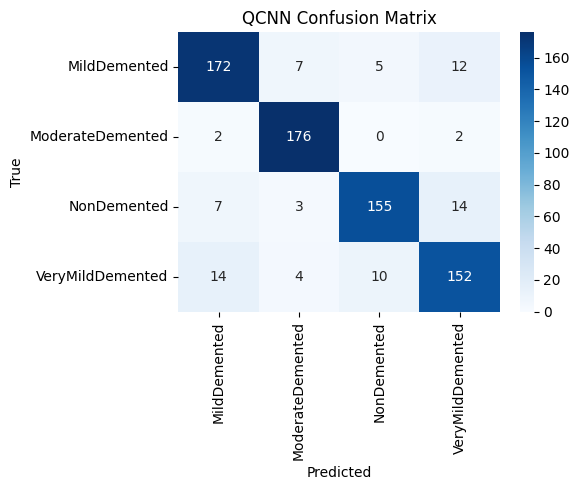


================ CNN TEST RESULTS ================
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8807 - loss: 0.5029 

CNN Test Accuracy: 0.8721
CNN Test Loss: 0.4794
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step

Classification Report (CNN):
                  precision    recall  f1-score   support

    MildDemented       0.86      0.85      0.85       196
ModerateDemented       0.96      0.94      0.95       180
     NonDemented       0.80      0.92      0.86       179
VeryMildDemented       0.89      0.77      0.82       180

        accuracy                           0.87       735
       macro avg       0.88      0.87      0.87       735
    weighted avg       0.88      0.87      0.87       735



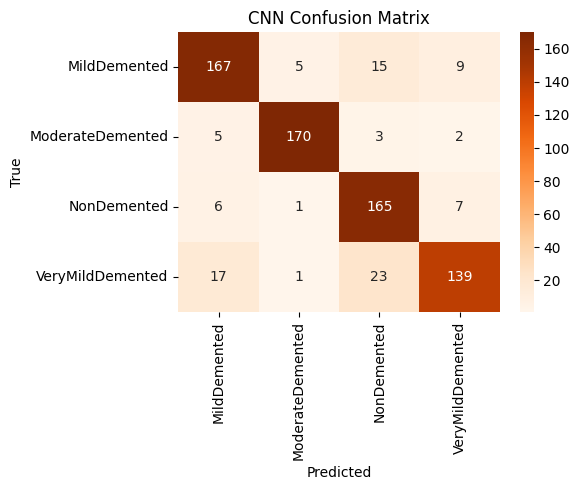

In [4]:
# ==================== IMPORTS ====================
!pip install pennylane --quiet
import os
import numpy as np
import cv2
from tqdm import tqdm
import pennylane as qml
import tensorflow as tf
from tensorflow import keras as K
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==================== CONFIG ====================
TEST_PATH = "/kaggle/input/qfeatures-and-mri/Quantum_features_/test"
IMG_SIZE = 64
PATCH_SIZE = 2
WIRES = 4

# ==================== QUANTUM CIRCUIT ====================
dev = qml.device("default.qubit", wires=WIRES)

@qml.qnode(dev)
def quantum_patch_circuit(phi):
    qml.RX(phi[0], wires=0)
    qml.RX(phi[1], wires=1)
    qml.RX(phi[2], wires=2)
    qml.RX(phi[3], wires=3)

    qml.CNOT(wires=[0, 1])
    qml.RZ(np.pi / 2, wires=1)
    qml.CNOT(wires=[0, 1])

    qml.CNOT(wires=[2, 3])
    qml.RZ(np.pi / 2, wires=3)
    qml.CNOT(wires=[2, 3])

    qml.CNOT(wires=[1, 2])
    qml.RZ(np.pi / 2, wires=2)
    qml.CNOT(wires=[1, 2])

    return [qml.expval(qml.PauliZ(i)) for i in range(4)]

def extract_q_features(image, patch_size=PATCH_SIZE):
    h, w = image.shape
    features = []
    for i in range(0, h - patch_size + 1, patch_size):
        for j in range(0, w - patch_size + 1, patch_size):
            patch = image[i:i + patch_size, j:j + patch_size].flatten()
            if patch.shape[0] < WIRES:
                patch = np.concatenate([patch, np.zeros(WIRES - patch.shape[0])])
            features.append(quantum_patch_circuit(patch))
    return np.array(features).flatten()

# ==================== LOAD TEST DATA ====================
def load_test_images(path, img_size=64):
    images, labels = [], []
    classes = sorted(os.listdir(path))
    class_to_idx = {cls: i for i, cls in enumerate(classes)}

    for cls in classes:
        cls_folder = os.path.join(path, cls)
        for file in tqdm(os.listdir(cls_folder), desc=f"Loading {cls}", leave=False):
            fp = os.path.join(cls_folder, file)
            img = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size)) / 255.0
            images.append(img)
            labels.append(class_to_idx[cls])
    return np.array(images), np.array(labels), classes

X_test_imgs, y_test, class_names = load_test_images(TEST_PATH, IMG_SIZE)

# ==================== QUANTUM FEATURE EXTRACTION ====================
q_features_test = []
for img in tqdm(X_test_imgs, desc="Extracting Quantum Features"):
    q_features_test.append(extract_q_features(img))
q_features_test = np.array(q_features_test)

# ==================== LOAD TRAINED MODELS ====================
qcnn_model = K.models.load_model("/kaggle/working/qcnn_model_15epochs.h5")
cnn_model = K.models.load_model("/kaggle/working/cnn_model_15epochs.h5")

# ==================== CLEAN MODEL SUMMARY FUNCTION ====================
def concise_summary(model, title, is_qcnn=False):
    print(f"\n──────────────── {title} ────────────────")
    if is_qcnn:
        print(f"QConv        | 4 wires      |             ")

    for layer in model.layers:
        if isinstance(layer, (K.layers.Dense, K.layers.Conv2D)):
            name = layer.__class__.__name__
            config = layer.get_config()
            units = config.get("units", "")
            kernel = config.get("kernel_size", "")
            param_str = f"{units}" if units else str(kernel)
            print(f"{name:<12} | {param_str:<12} | params: {layer.count_params():,}")
    print(f"─────────────────────────────────────────────")

# ==================== PRINT SUMMARIES ====================
concise_summary(qcnn_model, "QCNN", is_qcnn=True)
concise_summary(cnn_model, "CNN", is_qcnn=False)

# ==================== EVALUATE QCNN ====================
print("\n================ QCNN TEST RESULTS ================")
test_loss_q, test_acc_q = qcnn_model.evaluate(q_features_test, y_test, verbose=1)
print(f"\nQCNN Test Accuracy: {test_acc_q:.4f}")
print(f"QCNN Test Loss: {test_loss_q:.4f}")

y_pred_q = np.argmax(qcnn_model.predict(q_features_test), axis=1)
print("\nClassification Report (QCNN):")
print(classification_report(y_test, y_pred_q, target_names=class_names))

cm_q = confusion_matrix(y_test, y_pred_q)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_q, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("QCNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# ==================== EVALUATE CNN ====================
print("\n================ CNN TEST RESULTS ================")
X_test_cnn = X_test_imgs[..., np.newaxis]
test_loss_c, test_acc_c = cnn_model.evaluate(X_test_cnn, y_test, verbose=1)
print(f"\nCNN Test Accuracy: {test_acc_c:.4f}")
print(f"CNN Test Loss: {test_loss_c:.4f}")

y_pred_c = np.argmax(cnn_model.predict(X_test_cnn), axis=1)
print("\nClassification Report (CNN):")
print(classification_report(y_test, y_pred_c, target_names=class_names))

cm_c = confusion_matrix(y_test, y_pred_c)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_c, annot=True, fmt="d", cmap="Oranges",
            xticklabels=class_names, yticklabels=class_names)
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()
